# 複数マイクロフォンアレイによるスポットフォーミング

- チェックから始まる項はそれぞれのアルゴリズムチェック
- 最後の「スポットフォーミング」が実際のアルゴリズムの実装

## スポットフォーミング

In [556]:
import pyroomacoustics as pra
import numpy as np
from scipy.signal import stft
import matplotlib.pyplot as plt
from numpy.fft import rfft, irfft, rfftfreq
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter
from sklearn.decomposition import NMF
from pydub import AudioSegment

In [557]:
num_microphones = 8 # 1つのマイクロフォンアレイに含まれるマイクの数
mic_num = 4 # マイクロフォンアレイの数
use_noise = False # ノイズを使用するかどうか
music_num_src = 2 # MUSIC法で仮定する音源数
k = 2 # ビームフォーミングで利用するピーク点の数
source_loc = [5.5, 5.5, 0.3]

In [558]:
# MUSIC/DS beamforming定義
def doa(mic_signals, mic_loc, fs, nfft=512, noverlap=512//2, c=343.0, num_src=3):
    # mic_signals: 入力波形 shape: (マイク数, 時間)
    # mic_loc: マイク位置
    # fs: サンプリング周波数
    # nfft: FFT長
    # c: 音速
    # num_src: 推定する音源数
    # 各チャネルでSTFTを実行
    stft_results = []
    for i in range(mic_signals.shape[0]):
        f, t, Zxx = stft(mic_signals[i,:], fs=fs, nperseg=nfft, noverlap=noverlap)
        stft_results.append(Zxx)
    Z=np.array(stft_results) # shape: (マイク数, 周波数ビン数, タイムフレーム数)
    # MUSICオブジェクトを初期化
    music = pra.doa.MUSIC(mic_loc, fs=fs, nfft=nfft, c=c, num_src=num_src)
    # 実行
    music.locate_sources(Z)
    return music

# -----------------------------
# 幾何&ステアリングベクトル
# -----------------------------
def circular_array_positions(num_mics: int, radius_m: float) -> np.ndarray:
    """
    円形マイクアレイの各マイク座標を返す（xy平面、z=0）。
    返り値: shape = (num_mics, 3)
    """
    angles = np.linspace(0, 2*np.pi, num_mics, endpoint=False)
    x = radius_m * np.cos(angles)
    y = radius_m * np.sin(angles)
    z = np.zeros_like(x)
    return np.stack([x, y, z], axis=1)

def unit_vec_from_angles(azimuth_deg: float, elevation_deg: float) -> np.ndarray:
    """
    方位角(0°=x軸正方向, 反時計回り)・仰角(0°=xy平面, +で上向き)から単位ベクトルuを生成。
    """
    az = np.deg2rad(azimuth_deg)
    el = np.deg2rad(elevation_deg)
    u = np.array([
        np.cos(el) * np.cos(az),
        np.cos(el) * np.sin(az),
        np.sin(el)
    ], dtype=float)
    return u / np.linalg.norm(u)

def steering_vector(freqs: np.ndarray,
                    mic_positions: np.ndarray,
                    doa_unitvec: np.ndarray,
                    c: float = 343.0) -> np.ndarray:
    """
    ステアリングベクトル a(f, u) を返す。
    a_m(f) = exp( -j 2π f τ_m ), τ_m = (r_m · u)/c
    返り値: shape = (K, M)  (K=len(freqs), M=num_mics)
    """
    # 各マイクの幾何遅延（到来時間差）
    taus = -(mic_positions @ doa_unitvec) / c  # shape: (M,)
    # f×tau の外積 → 位相項
    phase = -2j * np.pi * freqs[:, None] * taus[None, :]  # (K, M)
    return np.exp(phase)

# -----------------------------
# DS（Delay-and-Sum）ビームフォーミング
# -----------------------------
def ds_beamform_time(y_multi: np.ndarray,
                     fs: int,
                     mic_positions: np.ndarray,
                     azimuth_deg: float,
                     elevation_deg: float = 0.0,
                     c: float = 343.0,
                     normalize: bool = True) -> np.ndarray:
    """
    周波数領域で位相シフトして和を取る DS ビームフォーマ。
    y_multi: shape=(N, M) の観測（Mチャネル）
    返り値: shape=(N,) のビーム出力
    """
    assert y_multi.ndim == 2, "y_multi must be (N, M)"
    N, M = y_multi.shape
    # FFT（実数rFFT） (K=len(freqs), M=num_mics)
    Y = rfft(y_multi, axis=0)                # (K, M)
    freqs = rfftfreq(N, d=1.0/fs)            # (K,)
    # 目標DOAのステアリングベクトル
    u = unit_vec_from_angles(azimuth_deg, elevation_deg)
    A = steering_vector(freqs, mic_positions, u, c=c)     # (K, M)
    # DSは conj(a) を重みとして合成（= 到来方向に位相合わせ）
    # W = conj(A), 出力は各周波数で内積
    #Y_beam = np.sum(np.conj(A) * Y, axis=1)  # (K,)
    Y_beam = np.sum(A * Y, axis=1)  # (K,)
    if normalize:
        Y_beam /= M  # 振幅の正規化（任意）
    y_beam = irfft(Y_beam, n=N)
    return y_beam

In [559]:
def get_micarray_pos(x,y):
    radius = 0.03
    angles = np.linspace(0, 2 * np.pi, num_microphones, endpoint=False)
    center=[x,y,0.3]
    mic_loc = np.array([
        center[0] + radius * np.cos(angles),
        center[1] + radius * np.sin(angles),
        [center[2]] * num_microphones
    ])
    return mic_loc

# Room dimensions
room_dim = [10, 10, 3]
# Create a shoebox room
room = pra.ShoeBox(room_dim, fs=16000, max_order=17)
# Source location
room.add_source(source_loc)

# Microphone array location and configuration
# Create an 8-channel circular microphone array
mic_loc = []
for i in range(mic_num):
    theta = np.pi * 2 / mic_num * i
    mic_loc.append(get_micarray_pos(5 + 2*np.cos(theta), 5 + 2*np.sin(theta)))
for i in range(mic_num):
    room.add_microphone_array(mic_loc[i])
# Simulate the room impulse responses
room.compute_rir()

if use_noise:
    # Generate some white noise as the source signal
    signal = np.random.randn(16000)
else:
    # mp3を読み込み
    path = "test_sound.mp3"
    sound = AudioSegment.from_file(path, format="mp3")
    signal = np.array(sound.get_array_of_samples())
room.sources[0].signal = signal

# Simulate the received signals at the microphones
room.simulate()
print(room.mic_array.signals.shape)


(32, 191126)


In [560]:
signal_list = []
for i in range(mic_num):
    start_idx = i * num_microphones
    end_idx = (i + 1) * num_microphones
    signals = room.mic_array.signals[start_idx:end_idx]
    signal_list.append(signals)
music_list = []
for i in range(mic_num):
    music = doa(signal_list[i], mic_loc[i], fs=room.fs, num_src=music_num_src)
    music_list.append(music)

Text(0.5, 1.0, 'simulation setting')

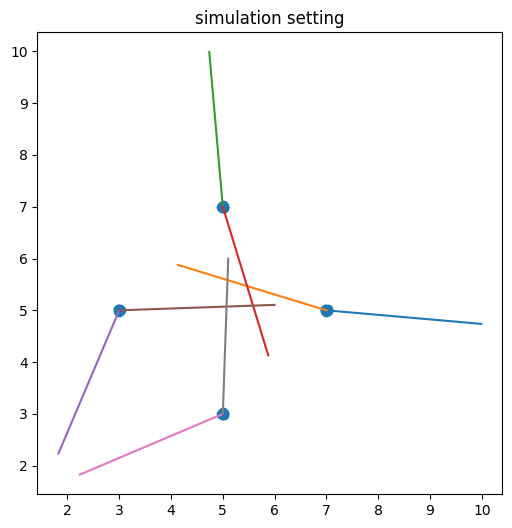

In [561]:
# 図を正方形にする
fig = plt.gcf()
fig.set_size_inches(6,6)
plt.axis("equal")

mic_loc = np.array(mic_loc)
plt.scatter(mic_loc[:, 0], mic_loc[:, 1])

for i in range(mic_num):
    music = music_list[i]
    loc = mic_loc[i]
    theta = music.azimuth_recon
    x1 = np.mean(loc[0])
    y1 = np.mean(loc[1])
    x2_list = np.mean(loc[0]) + np.cos(theta)*3.0
    y2_list = np.mean(loc[1]) + np.sin(theta)*3.0
    for x2,y2 in zip(x2_list, y2_list):
        plt.plot([x1, x2], [y1, y2])
plt.title("simulation setting")

Text(0.5, 0, 'direction')

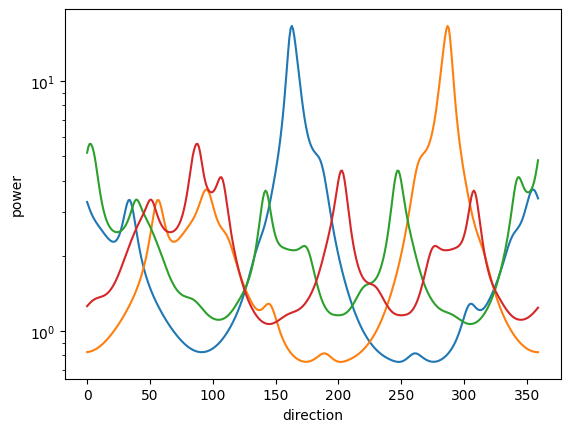

In [562]:
for i in range(mic_num):
    plt.plot(np.mean(music_list[i].Pssl, axis=1))
plt.yscale("log")
plt.ylabel("power")
plt.xlabel("direction")

In [563]:
def make_2dmap(N, map_scale, music_list, mic_loc_list):
    X = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            for music, loc in zip(music_list, mic_loc_list):
                spec = np.log10(np.mean(music.Pssl, axis=1))
                spec /= np.sum(spec)
                cx = np.mean(loc[0])
                cy = np.mean(loc[1])
                x = i/map_scale
                y = j/map_scale
                theta = np.atan2((y-cy), (x-cx))
                d = np.sqrt((y-cy)**2+(x-cx)**2)
                X[i,j] += spec[int(theta / (2*np.pi / len(spec)))] / (d + 10)
    return X

map_scale = 10

X = make_2dmap(N=100, map_scale=map_scale, music_list=music_list, mic_loc_list=mic_loc)

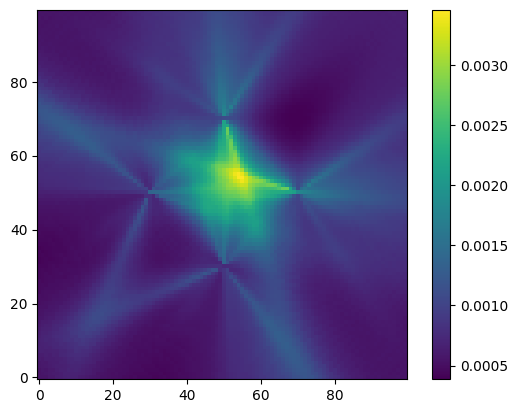

In [564]:
plt.imshow(X.T,origin="lower") # 座標を通常のx-yに合わせてプロット
plt.colorbar()

上位 2 個のピーク点
--------------------
True: (5.5, 5.5)
peak: (5.4, 5.4)
--------------------
True: (5.5, 5.5)
peak: (5.0, 7.3)


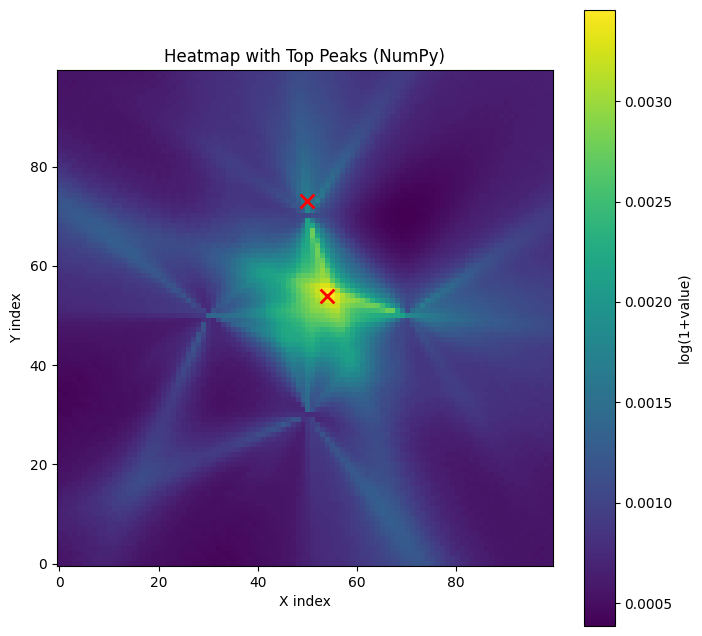

In [565]:
def find_top_k_peaks_numpy(data, k, map_scale, distance=10):
    """
    2次元データからピーク点を抽出し、ピーク点らしさ順にk個選択する（NumPyを使用）

    Args:
        data (np.ndarray): 2次元データ (N, M)
        k (int): 選択するピーク点の数
        map_scale: 座標とインデックスのスケールの違い
        distance (int): ピーク点として検出する際の最小距離

    Returns:
        list: ピーク点の座標 (row, col) のリスト。ピーク点らしさ順にソートされる。
    """
    # ローカル最大値を検出（近傍8点と比較）
    # dataを上下左右、斜めにシフトさせたものと比較
    is_peak = np.ones_like(data, dtype=bool)
    for dr in [-1, 0, 1]:
        for dc in [-1, 0, 1]:
            if dr == 0 and dc == 0:
                continue
            # シフトした配列を作成
            shifted_data = np.roll(data, shift=(dr, dc), axis=(0, 1))
            # 元のデータがシフトしたデータ以上であるか（境界を除く）
            # ロールバックして比較
            comparison = data >= shifted_data
            # 境界処理: ロールした際に反対側から来た部分を False にする
            if dr != 0:
                if dr == 1:
                    comparison[:dr, :] = True # 上端から来た部分
                else:
                    comparison[dr:, :] = True # 下端から来た部分
            if dc != 0:
                if dc == 1:
                    comparison[:, :dc] = True # 左端から来た部分
                else:
                    comparison[:, dc:] = True # 右端から来た部分
            is_peak &= comparison
    # ピーク点のインデックスを取得
    peak_rows, peak_cols = np.where(is_peak)
    # ピーク点らしさを評価（ここでは単純にピーク値を使用）
    # または、近傍との差の合計なども考えられるが、今回は簡潔さのためピーク値
    peak_values = data[peak_rows, peak_cols]
    # ピーク値の高い順にソートし、上位k個を選択
    sorted_indices = np.argsort(peak_values)[::-1]
    top_k_indices = sorted_indices[:k]
    top_k_peaks = [(peak_rows[i]/map_scale, peak_cols[i]/map_scale) for i in top_k_indices]
    # distance パラメータを考慮して、近すぎるピークをフィルタリングすることも可能ですが、
    # この実装では単純なローカル最大値検出に基づいています。
    # より厳密な距離ベースのフィルタリングが必要な場合は、別途実装が必要です。
    # 例: ピーク間の距離を計算し、近いものを排除
    return top_k_peaks
# ガウシアンフィルタで細かいピークを除去
X2 = gaussian_filter(X, 1)
top_peaks = find_top_k_peaks_numpy(X2, k, map_scale=map_scale)
print(f"上位 {k} 個のピーク点")
for peak in top_peaks:
    print("-"*20)
    print(f"True: ({source_loc[0]}, {source_loc[1]})")
    print(f"peak: ({peak[0]}, {peak[1]})")
# ピーク点を元の画像に重ねて表示
plt.figure(figsize=(8, 8))
plt.imshow(np.log1p(X).T, cmap='viridis',origin="lower")
plt.colorbar(label='log(1+value)')
plt.title('Heatmap with Top Peaks (NumPy)')
plt.xlabel('X index')
plt.ylabel('Y index')
# ピーク点にマーカーを追加
for peak in top_peaks:
    plt.scatter(peak[0]*map_scale, peak[1]*map_scale, color='red', marker='x', s=100, linewidths=2)
plt.show()

In [566]:
def get_peek_direction_from_mic(top_peaks, mic_loc):
  #top_peaksのマイク位置からの角度
  dx=np.array(top_peaks)-np.mean(mic_loc,axis=1)[:2]
  return np.atan2(dx[:,1],dx[:,0])

In [567]:
# マイクの数 x 推定音源位置（ピークの数）のBeamformingによる強調音声の取得

beamform_wav=[]
for mic_loc,signal in zip(mic_loc,signal_list):
  pos=mic_loc.T
  cm=np.mean(pos,axis=0)
  pos=pos-cm
  theta_list=get_peek_direction_from_mic(top_peaks, mic_loc)
  wav=[]
  for theta in theta_list:
    print("DS: mic=",cm,"theta=",theta)
    wav.append(ds_beamform_time(signal.T, fs=room.fs, mic_positions=pos,azimuth_deg=theta))
  beamform_wav.append(wav)

DS: mic= [7.  5.  0.3] theta= 2.896613990462929
DS: mic= [7.  5.  0.3] theta= 2.2865399164637767
DS: mic= [5.  7.  0.3] theta= -1.325817663668032
DS: mic= [5.  7.  0.3] theta= 1.5707963267948966
DS: mic= [3.  5.  0.3] theta= 0.16514867741462697
DS: mic= [3.  5.  0.3] theta= 0.8550527371260165
DS: mic= [5.  3.  0.3] theta= 1.4056476493802696
DS: mic= [5.  3.  0.3] theta= 1.5707963267948966


In [ ]:

def select_binary_mask(beamform_wav, index_estimated_src, fs, threshold=0.01, n_components = 3):
  n_estimated_src=len(beamform_wav[0])
  all_mic_results=[]
  for wavs in beamform_wav:
    wav=wavs[index_estimated_src]
    # パワースペクトログラムの計算
    f_stft, t_stft, Zxx = stft(wav, fs=fs)
    # パワースペクトログラム (振幅の2乗)
    power_spectrogram = np.abs(Zxx) ** 2
    model = NMF(n_components=n_components, init='random', random_state=0)
    # パワースペクトログラムをNMFに適用
    # NMFは非負の入力データを想定しているため、power_spectrogramを使用します。
    # fit_transformメソッドで分解と同時に変換を行います。
    W = model.fit_transform(power_spectrogram) # 基底 (Basis)
    H = model.components_ # アクティベーション (Activation)
    all_mic_results.append((wav,power_spectrogram, W, H))
  _,_,_,H = all_mic_results[0]
  M=H
  for _,_,_,H in all_mic_results[1:]:
    M=np.minimum(M,H)
  Mask=M>threshold
  return f_stft, t_stft, Mask, all_mic_results

# 最終的に各スポットごとに平均化してスペクトログラムを再構成
def recons_spec(beamform_wav, n_components, fs=None, plot_mask=False,plot_spec=False):
  n_estimated_src=len(beamform_wav[0])
  for i in range(n_estimated_src):
    f_stft, t_stft, Mask, results = select_binary_mask(beamform_wav,n_components=n_components,fs=fs, index_estimated_src=i, threshold=0.01)
    if plot_mask:
      # マスクの表示
      plt.imshow(Mask, aspect='auto', origin='lower', cmap='viridis', interpolation=None)
      plt.yticks(list(range(n_components)))
      plt.title('Mask from Hs')
      plt.xlabel('Time Frames')
      plt.ylabel('Components')
      plt.show()
    recons = [W @ (Mask * H) for wav, power_spectrogram, W, H in results]
    recons_all = np.mean(recons, axis=0)
    if plot_spec:
      # 再構成パワースペクトログラムの表示
      plt.figure(figsize=(10, 4))
      plt.pcolormesh(t_stft, f_stft, 10 * np.log10(recons_all + 1e-10), shading='gouraud')
      plt.title('Power Spectrogram of Beamformed Signal')
      plt.ylabel('Frequency [Hz]')
      plt.xlabel('Time [sec]')
      plt.colorbar(label='Power [dB]')
      plt.ylim([0, fs / 2])  # サンプリング周波数の半分までを表示
      plt.show()
  return recons, f_stft, t_stft

In [569]:
# beamform_wavからスポットのスペクトログラムを再構成する
X_recons,f_stft, t_stft = recons_spec(beamform_wav, n_components=16, fs=room.fs, plot_mask=False, plot_spec=False)

In [570]:
X_recons = np.array(X_recons)
recons_spec = np.mean(X_recons, axis=0) # 129, 190

beamform_wav = np.array(beamform_wav)
beamform_spec=[]
for wavs in beamform_wav:
    for wav in wavs:
        f_stft, t_stft, Zxx = stft(wav, fs=room.fs)
        power_spectrogram = np.abs(Zxx) ** 2
        beamform_spec.append(power_spectrogram)
beamform_spec = np.array(beamform_spec)
mean_spec = np.mean(beamform_spec, axis=0) # 129, 190
print(recons_spec.shape)
print(mean_spec.shape)

(129, 1495)
(129, 1495)


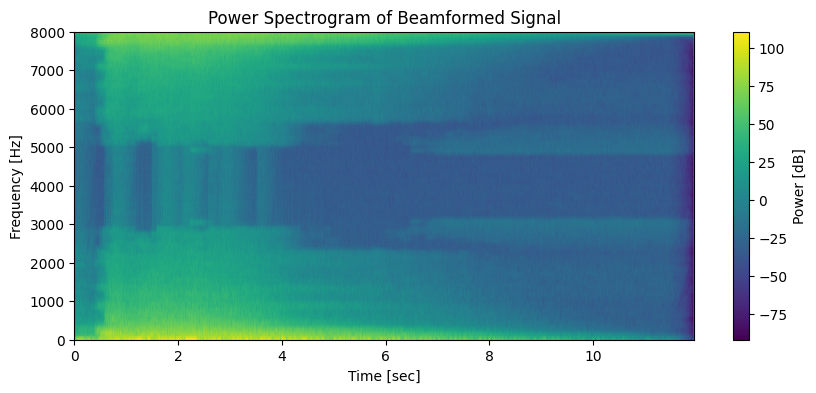

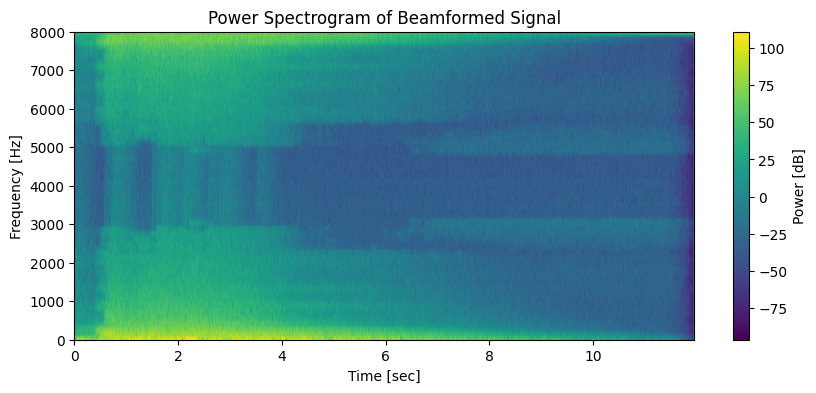

In [571]:
# 最終的に各スポットのスペクトログラムを表示

# 再構成パワースペクトログラムの表示
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_stft, f_stft, 10 * np.log10(mean_spec + 1e-10), shading='gouraud')
plt.title('Power Spectrogram of Beamformed Signal')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Power [dB]')
plt.ylim([0, room.fs / 2])  # サンプリング周波数の半分までを表示
plt.show()

# 再構成パワースペクトログラムの表示
plt.figure(figsize=(10, 4))
plt.pcolormesh(t_stft, f_stft, 10 * np.log10(beamform_spec[1] + 1e-10), shading='gouraud')
plt.title('Power Spectrogram of Beamformed Signal')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Power [dB]')
plt.ylim([0, room.fs / 2])  # サンプリング周波数の半分までを表示
plt.show()

